# Transformer vs statistical dependence models: backtest analysis

Head-to-head comparison of the three new gallery entries on the Meyers
retrospective protocol (train on the upper triangle as of **1997-12-31**,
score the realized ultimates from later diagonals):

| entry | family | dependence mechanism | fit shape |
|---|---|---|---|
| `nn_transformer` | nn | attention over the full triangle grid; pooled across every company x LOB | one market fit, per-segment predicts |
| `sur` | statistical | contemporaneous error correlation across LOBs per dev transition (Zhang 2010 FGLS) | per company, all LOBs jointly |
| `copula_glm` | statistical | Gaussian copula across LOBs within each (origin, dev) cell (Shi & Frees 2011) | per company, all LOBs jointly |

Headline field is **paid_loss** (the copula's lognormal marginals cannot take
the negative late increments of reported losses). Results were produced by
`scripts/compare_gallery.py`; this notebook only analyzes the committed
artifact. Company set: insurers passing Meyers' Table A.1 screens on **all
four** Schedule P lines.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ibnr.kernels.calibration import ks_uniformity, pp_points

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110

RESULTS = Path("results/compare_gallery.csv")
df = pd.read_csv(RESULTS, dtype={"company_code": str})
MODELS = ["sur", "copula_glm", "nn_transformer"]
LINES = sorted(df.loc[df["line"] != "ALL", "line"].unique())

print(f"data publish: {df['mart_publish_id'].iloc[0]}   loss field: {df['loss_field'].iloc[0]}")
print(f"{df['company_code'].nunique()} companies x {len(LINES)} lines; {len(df)} result rows")
failed = df[df["error"].notna()] if "error" in df else pd.DataFrame()
print(f"failed fits: {len(failed)}")

data publish: 20260613_041006   loss field: paid_loss
6 companies x 4 lines; 84 result rows
failed fits: 0


## Results table

One row per (model, line, company): the predictive mean of the line-total
ultimate, its spread, the realized outcome, the outcome's percentile in the
predictive distribution, and the CRPS. `line == "ALL"` rows are the
multiline models' *diversified grand totals* — sums across lines inside the
same draws.

In [2]:
ok = df[df["percentile"].notna() & (df["line"] != "ALL")].copy()
ok["err_pct"] = (ok["estimate"] - ok["outcome"]) / ok["outcome"] * 100
display_cols = [
    "model",
    "line",
    "company_code",
    "estimate",
    "outcome",
    "err_pct",
    "cv",
    "percentile",
    "crps",
]
ok[display_cols].sort_values(["line", "company_code", "model"]).round(2)

,model,line,company_code,estimate,outcome,err_pct,cv,percentile,crps
30,copula_glm,commercial_auto,14176,29639.20,21764.0,36.18,0.50,14.59,3016.02
60,nn_transformer,commercial_auto,14176,25768.02,21764.0,18.40,0.31,26.10,1712.20
0,sur,commercial_auto,14176,23800.23,21764.0,9.36,0.07,12.00,1228.78
35,copula_glm,commercial_auto,1538,94861.03,90687.0,4.60,0.09,35.00,2015.71
61,nn_transformer,commercial_auto,1538,105209.72,90687.0,16.01,0.22,15.50,6971.25
...,...,...,...,...,...,...,...,...,...
76,nn_transformer,workers_compensation,5185,109754.73,103908.0,5.63,0.29,34.70,5627.50
22,sur,workers_compensation,5185,103213.40,103908.0,-0.67,0.02,64.34,553.47
57,copula_glm,workers_compensation,715,235725.45,237347.0,-0.68,0.04,62.48,2523.93
77,nn_transformer,workers_compensation,715,262631.72,237347.0,10.65,0.30,30.80,16653.57


## Calibration: are the predictive distributions honest?

If a model's uncertainty is right, realized outcomes should look like uniform
draws from their predictive CDFs (Meyers' PIT test). The p-p plot compares
sorted outcome percentiles against uniform quantiles; the KS band is the 5%
critical distance.

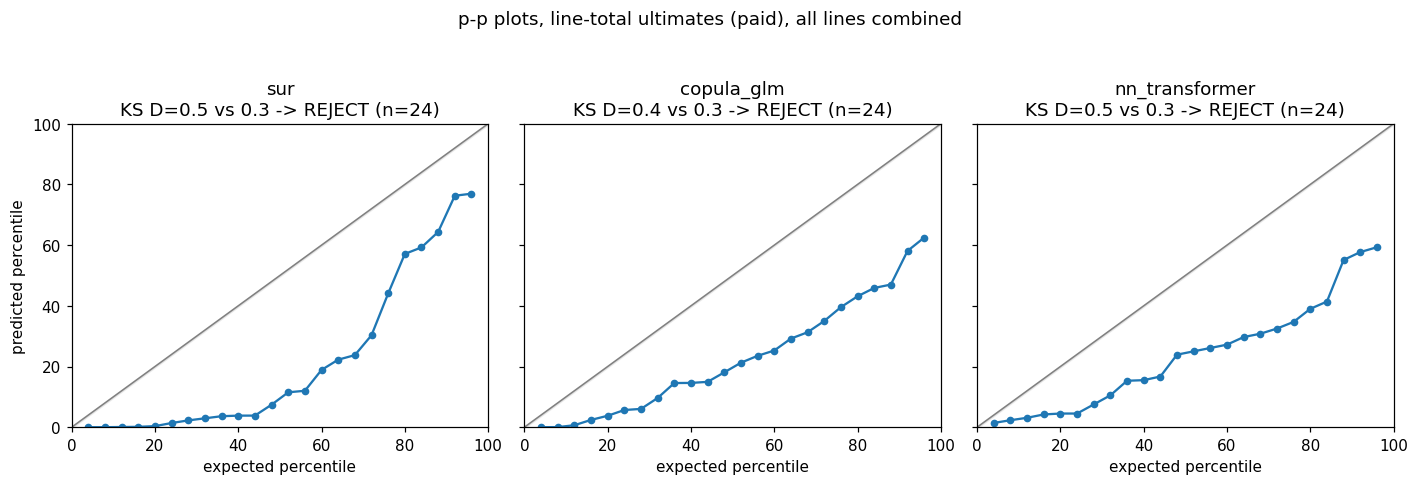

In [3]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(13, 4.2), sharey=True)
for ax, model in zip(axes, MODELS):
    pcts = ok.loc[ok["model"] == model, "percentile"] / 100
    expected, predicted = pp_points(pcts)
    ks = ks_uniformity(pcts)
    band = ks.critical_value_5pct
    ax.plot([0, 100], [0, 100], color="grey", lw=1)
    ax.fill_between([0, 100], [-band, 100 - band], [band, 100 + band], alpha=0.15, color="grey")
    ax.plot(expected, predicted, "o-", ms=4)
    verdict = "REJECT" if ks.reject_5pct else "pass"
    ax.set_title(f"{model}\nKS D={ks.statistic:.1f} vs {band:.1f} -> {verdict} (n={ks.n})")
    ax.set_xlabel("expected percentile")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
axes[0].set_ylabel("predicted percentile")
fig.suptitle("p-p plots, line-total ultimates (paid), all lines combined", y=1.04)
plt.tight_layout()
plt.show()

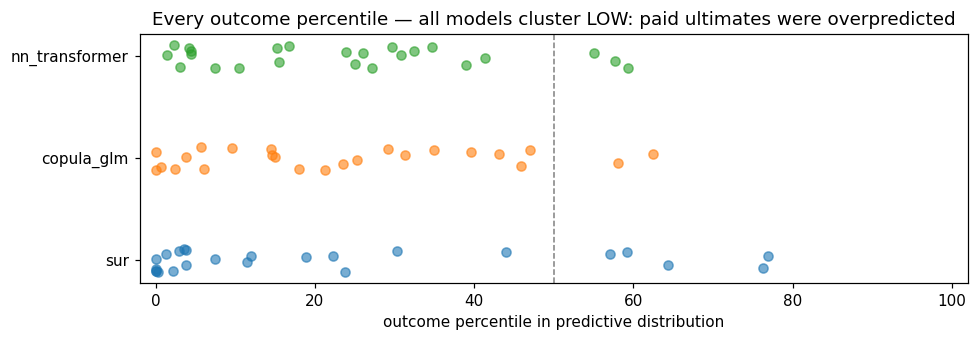

count  median  ks_d
model          line                                       
copula_glm     commercial_auto             6    16.3   0.6
               other_liability             6    23.3   0.5
               private_passenger_auto      6     7.6   0.8
               workers_compensation        6    43.3   0.4
nn_transformer commercial_auto             6    15.4   0.7
               other_liability             6    48.2   0.4
               private_passenger_auto      6     4.4   0.9
               workers_compensation        6    30.2   0.7
sur            commercial_auto             6     7.5   0.6
               other_liability             6    16.9   0.6
               private_passenger_auto      6     3.7   0.9
               workers_compensation        6    58.2   0.2

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.2))
for i, model in enumerate(MODELS):
    pcts = ok.loc[ok["model"] == model, "percentile"]
    ax.plot(
        pcts,
        np.full(len(pcts), i) + np.random.default_rng(0).uniform(-0.12, 0.12, len(pcts)),
        "o",
        alpha=0.6,
        label=model,
    )
ax.set_yticks(range(len(MODELS)), MODELS)
ax.set_xlabel("outcome percentile in predictive distribution")
ax.set_xlim(-2, 102)
ax.axvline(50, color="grey", lw=1, ls="--")
ax.set_title("Every outcome percentile — all models cluster LOW: paid ultimates were overpredicted")
plt.tight_layout()
plt.show()

per_line = (
    ok.groupby(["model", "line"])["percentile"]
    .agg(["count", "median"])
    .join(
        ok.groupby(["model", "line"])["percentile"]
        .apply(lambda p: ks_uniformity(p / 100).statistic)
        .rename("ks_d")
    )
    .round(1)
)
per_line

**Reading:** every model fails the combined KS at 5% with outcomes piled in
the left tail — realized paid ultimates came in *below* what all three models
predicted. This is the known post-1997 favorable-development regime on paid
Schedule P data: Meyers found the same one-sided bias for his paid-data
models (monograph ch. 7 — it's why his headline models moved to incurred).
It is a regime finding shared by every model in the study, not a defect of
any one of them; the *relative* comparison below is where the models
separate.

## Sharpness: CRPS

CRPS (lower = better) rewards distributions that are both calibrated and
tight. Scaled by the outcome so lines and companies are comparable.

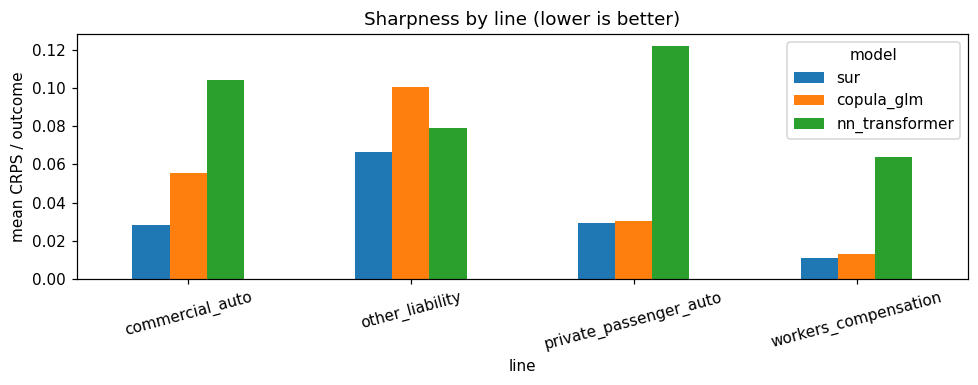

model,sur,copula_glm,nn_transformer
line,,,
commercial_auto,0.0281,0.0553,0.1041
other_liability,0.0663,0.1007,0.0792
private_passenger_auto,0.0294,0.0302,0.1221
workers_compensation,0.0109,0.0132,0.0637


In [5]:
rel = ok.assign(rel_crps=ok["crps"] / ok["outcome"])
pivot = rel.pivot_table(index="line", columns="model", values="rel_crps", aggfunc="mean")[MODELS]
axp = pivot.plot.bar(figsize=(9, 3.6), rot=15)
axp.set_ylabel("mean CRPS / outcome")
axp.set_title("Sharpness by line (lower is better)")
plt.tight_layout()
plt.show()
pivot.round(4)

## Bias

The signed reserve error per (model, line, company).

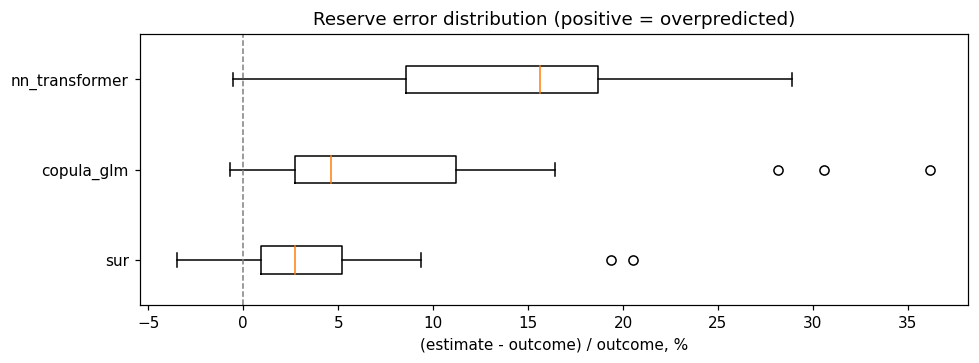

,count,mean,50%,min,max
model,,,,,
copula_glm,24.0,8.9,4.6,-0.7,36.2
nn_transformer,24.0,14.1,15.6,-0.6,28.9
sur,24.0,4.2,2.7,-3.5,20.5


In [6]:
fig, ax = plt.subplots(figsize=(9, 3.4))
data = [ok.loc[ok["model"] == m, "err_pct"] for m in MODELS]
ax.boxplot(data, labels=MODELS, vert=False)
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_xlabel("(estimate - outcome) / outcome, %")
ax.set_title("Reserve error distribution (positive = overpredicted)")
plt.tight_layout()
plt.show()
ok.groupby("model")["err_pct"].describe().round(1)[["count", "mean", "50%", "min", "max"]]

## Deep dive: dependence estimates and diversification (one company)

The point of the multiline models is the cross-line dependence. Refit both
statistical models on one company (fits are sub-second) and inspect what they
actually estimated, and what it does to the grand-total distribution.

In [7]:
import ibis

from ibnr import gallery
from ibnr.data.schedule_p import load_schedule_p

WAREHOUSE = Path("../../cas-schedule-p-data-model/warehouse")
CODE = ok["company_code"].iloc[0]
AS_OF = "1997-12-31"

tri = load_schedule_p(WAREHOUSE, lines=LINES).filter(ibis._.company_code == CODE)
sur = gallery.fit("sur", tri, loss_field="paid_loss", as_of=AS_OF)
try:
    cop = gallery.fit("copula_glm", tri, loss_field="paid_loss", as_of=AS_OF, nonpositive="drop")
except ValueError:  # dropped cells can deplete late dev factor effects
    cop = gallery.fit(
        "copula_glm",
        tri,
        loss_field="paid_loss",
        as_of=AS_OF,
        nonpositive="drop",
        dev_effect="hoerl",
    )
print(f"company {CODE}: SUR transition methods -> {[t['method'] for t in sur.transitions_]}")

company 14176: SUR transition methods -> ['fgls', 'fgls', 'fgls', 'fgls', 'pooled_corr', 'pooled_corr', 'pooled_corr', 'tail', 'tail']


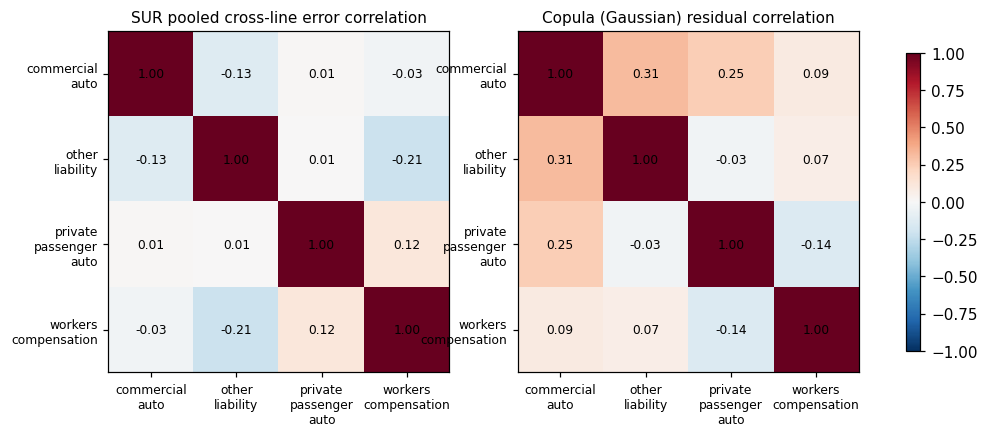

In [8]:
lobs = sur.contract_["lobs"]
short = [lob.replace("_", "\n") for lob in lobs]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (mat, title) in zip(
    axes,
    [
        (sur.pooled_corr_, "SUR pooled cross-line error correlation"),
        (cop.corr_, "Copula (Gaussian) residual correlation"),
    ],
):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(lobs)), short, fontsize=8)
    ax.set_yticks(range(len(lobs)), short, fontsize=8)
    for i in range(len(lobs)):
        for j in range(len(lobs)):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(title, fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

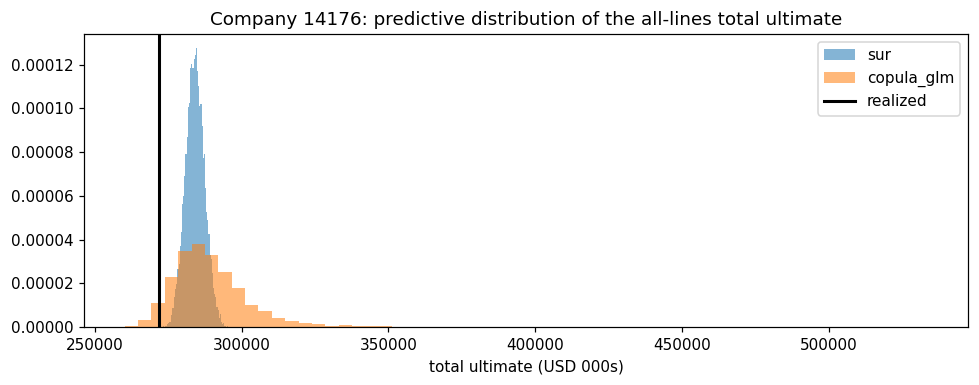

,sum of per-line sd,grand-total sd,implied diversification
sur,6577.518,3242.527,0.507
copula_glm,22184.139,14619.565,0.341


In [9]:
pred_sur = sur.predict(n_draws=10_000, seed=0)
pred_cop = cop.predict(n_draws=10_000, seed=0)
realized = sur.realized_ultimates(tri)

n_cells = len(lobs) * sur.contract_["n_w"]
per_lob_sd_sur = pred_sur.std()[n_cells : n_cells + len(lobs)]
per_lob_sd_cop = pred_cop.std()[n_cells : n_cells + len(lobs)]
div = pd.DataFrame(
    {
        "sum of per-line sd": [per_lob_sd_sur.sum(), per_lob_sd_cop.sum()],
        "grand-total sd": [pred_sur.std()[-1], pred_cop.std()[-1]],
    },
    index=["sur", "copula_glm"],
)
div["implied diversification"] = 1 - div["grand-total sd"] / div["sum of per-line sd"]

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(pred_sur.samples[:, -1], bins=60, alpha=0.55, density=True, label="sur")
ax.hist(pred_cop.samples[:, -1], bins=60, alpha=0.55, density=True, label="copula_glm")
ax.axvline(realized[-1], color="black", lw=2, label="realized")
ax.set_title(f"Company {CODE}: predictive distribution of the all-lines total ultimate")
ax.set_xlabel("total ultimate (USD 000s)")
ax.legend()
plt.tight_layout()
plt.show()
div.round(3)

Positive cross-line correlation means the grand-total sd shrinks *less* than
independence would imply — that gap is exactly the dependence the manuscript
is about. The transformer expresses the same thing implicitly (shared encoder
context across a company's lines) rather than through an explicit correlation
parameter; comparing its implied cross-line dependence against these explicit
estimates is the next experiment.

## The transformer's showing, and caveats

- **Sharpness**: the transformer's CRPS is ~2-4x the statistical models'.
  With ~400 cohorts x ~55 cells it cannot yet beat models whose inductive
  bias *is* the development process. This is the honest baseline the research
  needs on record; levers not yet pulled: HPO (`kernels/tuning.py`, deferred),
  reported-loss features, longer training, company covariates.
- **Calibration**: all models share the paid-regime bias; on relative terms
  the transformer's p-p curve is comparable to the copula's and slightly
  worse than SUR's.
- **n = 6 companies** pass the screens on all four lines — per-line KS has
  little power; the combined n=24 is the meaningful test. Widening to 2-line
  subsets (`--lines`) multiplies the sample.
- The pooled transformer fit costs ~20 min CPU; rerun the study with
  `uv run python scripts/compare_gallery.py` (see `--help` for `--models`,
  `--lines`, `--nn-draws`; add `meyers_ccl` for the Bayesian benchmark).